<a href="https://colab.research.google.com/github/rawan-afk/AgriVision-DeepLabV3/blob/main/Credit_Card_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import imblearn as imb
import seaborn as sns

In [152]:
filename = '/content/credit_card_churn_dataset_V2.xlsx'
df = pd.read_excel(filename)

In [153]:
df.head()

,index,age,gender,marital_status,education_level,employment_status,num_dependents,residence_type,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_month,total_spend_last_3_months,total_spend_last_6_months,total_spend_last_year,average_monthly_spend,max_monthly_spend,min_monthly_spend,average_transaction_value,num_transactions_last_month,num_transactions_last_3_months,num_transactions_last_6_months,num_transactions_last_year,average_monthly_transactions,max_monthly_transactions,min_monthly_transactions,decreasing_spend_trend,spend_volatility,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,expiration_date,acc_ref_num,previous_cards,longevity_in_months,feature_1,feature_2,feature_3,credit_limit,credit_limit_utilization,average_payment_delay,monthly_active_days,num_other_products,account_types,loyalty_score,transaction_frequency,total_bank_balance,act_ref_num,plastic_masked_pan
0,5464,22,Male,Single,Master,Self-Employed,3,Rent,3,4664.0,7438.0,15398.000000,760,4884.056742,2211,6555.000000,40001,134147.488984,229021.456622,510289.503743,39761.617291,48092.489848,20537.322607,179.320620,19,56,121,230,13,26,10,1,High,0,1,8,1,2025-08-27 19:02:25.599,952043535551,1,37,554856.956821,20,179.536381,760000,0.675217,0,0.542960,4,loan,251.7,44,514953.503743,SR010651,**** **** **** 4691
1,2042,25,Male,Married,NaN,Retired,2,Rent,1,NaN,8252.0,18864.429771,665,2970.000000,920,6430.319172,32342,101638.757719,196935.466907,367657.989538,14146.186657,40624.516991,17692.040772,331.481110,74,240,437,854,170,101,45,0,Low,1,1,3,0,2025-07-27 19:02:25.599,878089652769,9,95,372159.798988,75,336.412858,510000,0.730798,0,2.918925,40,checking,NaN,24,NaN,SR002042,**** **** **** 4806
2,8669,64,Female,Divorced,Bachelor,Employed,4,Own,8,1408.0,5199.0,4964.000000,882,1167.000000,2418,4967.000000,21005,52898.328993,117662.365738,237161.720388,17565.195841,28874.282596,12457.854688,283.348730,18,51,104,220,12,24,11,1,High,0,0,2,1,2024-10-12 19:02:25.599,653733701091,1,47,225409.082837,16,275.373265,310000,0.783904,0,0.705561,7,checking,93.9,42,238569.720388,SR008669,**** **** **** 2237
3,1115,61,Female,Single,Master,Employed,2,Own,8,NaN,1837.0,18270.000000,722,4808.275207,43,5992.000000,30275,86390.416083,188754.429687,370750.224323,19681.613661,38812.702037,17246.958911,121.543290,35,111,223,390,15,44,26,1,High,1,1,3,1,2028-10-13 19:02:25.599,215639822409,2,187,377641.724662,34,119.481675,520000,0.725752,0,0.935237,4,loan,NaN,10,NaN,SR001115,**** **** **** 6982
4,4078,58,Male,Married,NaN,Self-Employed,1,Rent,14,4134.0,7530.0,18272.775610,166,3256.000000,2736,7506.437574,23050,74438.420532,145501.563858,286910.970994,20698.827145,27802.368773,16321.431566,97.689565,69,185,391,774,14,99,44,1,High,1,1,0,1,2027-04-22 19:02:25.599,350623699852,1,120,293716.324870,70,98.019826,400000,0.721720,3,2.471756,6,checking,266.7,39,291044.970994,SR013903,**** **** **** 5168


In [154]:
df.columns

Index(['index', 'age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'num_dependents', 'residence_type',
       'years_at_residence', 'monthly_spend_cash', 'monthly_spend_payments',
       'monthly_spend_installments', 'monthly_spend_subscriptions',
       'monthly_spend_travel', 'monthly_spend_dining',
       'monthly_spend_shopping', 'total_spend_last_month',
       'total_spend_last_3_months', 'total_spend_last_6_months',
       'total_spend_last_year', 'average_monthly_spend', 'max_monthly_spend',
       'min_monthly_spend', 'average_transaction_value',
       'num_transactions_last_month', 'num_transactions_last_3_months',
       'num_transactions_last_6_months', 'num_transactions_last_year',
       'average_monthly_transactions', 'max_monthly_transactions',
       'min_monthly_transactions', 'decreasing_spend_trend',
       'spend_volatility', 'recent_large_transactions',
       'use_of_credit_card_for_emergencies', 'frequent_late_payments', 'churn',


In [155]:
df[['feature_1', 'feature_2', 'feature_3']].head()

,feature_1,feature_2,feature_3
0,554856.956821,20,179.536381
1,372159.798988,75,336.412858
2,225409.082837,16,275.373265
3,377641.724662,34,119.481675
4,293716.324870,70,98.019826


In [156]:
df[['acc_ref_num', 'act_ref_num']].head(5
                                      )

,acc_ref_num,act_ref_num
0,952043535551,SR010651
1,878089652769,SR002042
2,653733701091,SR008669
3,215639822409,SR001115
4,350623699852,SR013903


In [157]:
df['act_ref_num'].is_unique

True

In [158]:
df.head()

,index,age,gender,marital_status,education_level,employment_status,num_dependents,residence_type,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_month,total_spend_last_3_months,total_spend_last_6_months,total_spend_last_year,average_monthly_spend,max_monthly_spend,min_monthly_spend,average_transaction_value,num_transactions_last_month,num_transactions_last_3_months,num_transactions_last_6_months,num_transactions_last_year,average_monthly_transactions,max_monthly_transactions,min_monthly_transactions,decreasing_spend_trend,spend_volatility,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,expiration_date,acc_ref_num,previous_cards,longevity_in_months,feature_1,feature_2,feature_3,credit_limit,credit_limit_utilization,average_payment_delay,monthly_active_days,num_other_products,account_types,loyalty_score,transaction_frequency,total_bank_balance,act_ref_num,plastic_masked_pan
0,5464,22,Male,Single,Master,Self-Employed,3,Rent,3,4664.0,7438.0,15398.000000,760,4884.056742,2211,6555.000000,40001,134147.488984,229021.456622,510289.503743,39761.617291,48092.489848,20537.322607,179.320620,19,56,121,230,13,26,10,1,High,0,1,8,1,2025-08-27 19:02:25.599,952043535551,1,37,554856.956821,20,179.536381,760000,0.675217,0,0.542960,4,loan,251.7,44,514953.503743,SR010651,**** **** **** 4691
1,2042,25,Male,Married,NaN,Retired,2,Rent,1,NaN,8252.0,18864.429771,665,2970.000000,920,6430.319172,32342,101638.757719,196935.466907,367657.989538,14146.186657,40624.516991,17692.040772,331.481110,74,240,437,854,170,101,45,0,Low,1,1,3,0,2025-07-27 19:02:25.599,878089652769,9,95,372159.798988,75,336.412858,510000,0.730798,0,2.918925,40,checking,NaN,24,NaN,SR002042,**** **** **** 4806
2,8669,64,Female,Divorced,Bachelor,Employed,4,Own,8,1408.0,5199.0,4964.000000,882,1167.000000,2418,4967.000000,21005,52898.328993,117662.365738,237161.720388,17565.195841,28874.282596,12457.854688,283.348730,18,51,104,220,12,24,11,1,High,0,0,2,1,2024-10-12 19:02:25.599,653733701091,1,47,225409.082837,16,275.373265,310000,0.783904,0,0.705561,7,checking,93.9,42,238569.720388,SR008669,**** **** **** 2237
3,1115,61,Female,Single,Master,Employed,2,Own,8,NaN,1837.0,18270.000000,722,4808.275207,43,5992.000000,30275,86390.416083,188754.429687,370750.224323,19681.613661,38812.702037,17246.958911,121.543290,35,111,223,390,15,44,26,1,High,1,1,3,1,2028-10-13 19:02:25.599,215639822409,2,187,377641.724662,34,119.481675,520000,0.725752,0,0.935237,4,loan,NaN,10,NaN,SR001115,**** **** **** 6982
4,4078,58,Male,Married,NaN,Self-Employed,1,Rent,14,4134.0,7530.0,18272.775610,166,3256.000000,2736,7506.437574,23050,74438.420532,145501.563858,286910.970994,20698.827145,27802.368773,16321.431566,97.689565,69,185,391,774,14,99,44,1,High,1,1,0,1,2027-04-22 19:02:25.599,350623699852,1,120,293716.324870,70,98.019826,400000,0.721720,3,2.471756,6,checking,266.7,39,291044.970994,SR013903,**** **** **** 5168


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   index                               20000 non-null  int64         
 1   age                                 20000 non-null  int64         
 2   gender                              20000 non-null  object        
 3   marital_status                      20000 non-null  object        
 4   education_level                     10028 non-null  object        
 5   employment_status                   20000 non-null  object        
 6   num_dependents                      20000 non-null  int64         
 7   residence_type                      20000 non-null  object        
 8   years_at_residence                  20000 non-null  int64         
 9   monthly_spend_cash                  17985 non-null  float64       
 10  monthly_spend_payments

In [160]:
df.dtypes

,0
index,int64
age,int64
gender,object
marital_status,object
education_level,object
employment_status,object
num_dependents,int64
residence_type,object
years_at_residence,int64
monthly_spend_cash,float64


In [161]:
# mean, min , quartiles , max , standard diviation
df.describe()

,index,age,num_dependents,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_month,total_spend_last_3_months,total_spend_last_6_months,total_spend_last_year,average_monthly_spend,max_monthly_spend,min_monthly_spend,average_transaction_value,num_transactions_last_month,num_transactions_last_3_months,num_transactions_last_6_months,num_transactions_last_year,average_monthly_transactions,max_monthly_transactions,min_monthly_transactions,decreasing_spend_trend,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,expiration_date,acc_ref_num,previous_cards,longevity_in_months,feature_1,feature_2,feature_3,credit_limit,credit_limit_utilization,average_payment_delay,monthly_active_days,num_other_products,loyalty_score,transaction_frequency,total_bank_balance
count,20000.000000,20000.00000,20000.000000,20000.000000,17985.000000,18030.000000,18482.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,15993.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,15993.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,17985.000000,20000.000000,17985.000000
mean,4990.932100,43.43505,1.995350,14.994700,2517.592994,5070.738769,12244.760672,498.474700,2987.020820,1487.794250,4861.027906,26125.875000,78388.765800,156864.123897,313364.364880,18015.554706,35290.156895,17017.168217,262.483840,49.424750,147.847500,296.080050,593.182250,116.658550,66.214900,31.545350,0.440000,0.493550,0.507800,1.862700,0.350000,2027-01-22 05:17:31.359000320,5.465218e+11,5.180450,143.475700,313251.208497,49.439700,262.515332,427886.000000,0.743917,2.520000,1.646354,20.978200,197.475730,29.479650,316267.023803
min,1.000000,18.00000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,3846.000000,10296.162581,22255.088571,47159.300683,13015.414527,5650.094233,2083.547470,20.003155,1.000000,2.000000,5.000000,11.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024-08-06 19:02:25.599000,1.000552e+11,1.000000,1.000000,44622.835777,-1.000000,19.206050,60000.000000,0.666677,0.000000,0.026741,1.000000,4.200000,10.000000,47239.300683
25%,2505.000000,31.00000,1.000000,8.000000,1281.000000,2592.500000,6990.750000,245.000000,1664.000000,726.000000,2750.000000,20808.750000,61445.145624,124498.530143,249913.151516,15125.969714,27937.723771,13112.554140,142.110940,25.000000,73.000000,147.000000,295.000000,12.000000,33.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2025-11-05 19:02:25.599000064,3.227629e+11,2.000000,66.000000,247808.618981,25.000000,142.271524,340000.000000,0.701881,0.000000,0.813745,6.000000,128.400000,19.000000,252942.603208
50%,4982.000000,43.00000,2.000000,15.000000,2489.000000,5096.000000,13841.000000,501.000000,3306.000000,1486.000000,5474.500000,26080.500000,77892.042689,156539.033392,312033.395898,17177.308317,35145.705864,16775.211041,264.166205,49.000000,145.000000,292.000000,586.000000,161.000000,65.000000,31.000000,0.000000,0.000000,1.000000,2.000000,0.000000,2027-01-26 19:02:25.599000064,5.463735e+11,6.000000,129.000000,311305.673150,49.000000,263.024047,430000.000000,0.740917,0.000000,1.605619,25.000000,194.650000,30.000000,314843.408621
75%,7494.000000,56.00000,3.000000,22.000000,3803.000000,7625.000000,17646.683475,747.000000,4368.855641,2239.000000,7024.042983,31424.000000,94156.316446,188574.135384,376669.699664,19174.708200,42403.033754,20530.546832,383.687989,74.000000,219.000000,441.000000,885.000000,180.000000,99.000000,47.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2028-04-05 01:02:25.59900006

In [162]:
# Churn
df["churn"].value_counts()

,count
churn,
0,13000
1,7000




---


# ***EDA***


---



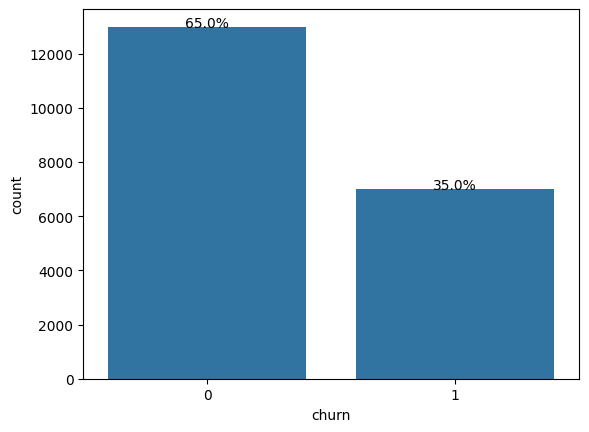

In [163]:
x = sns.countplot(x="churn", data=df)

total = len(df)

for p in x.patches:
    percentage = 100 * p.get_height() / total
    x.annotate(f'{percentage}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center')



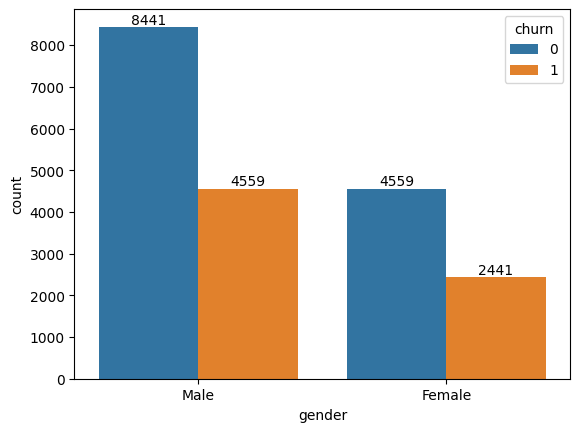

In [164]:
ax = sns.countplot(data=df, x='gender', hue='churn')

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()

<Axes: ylabel='average_transaction_value'>

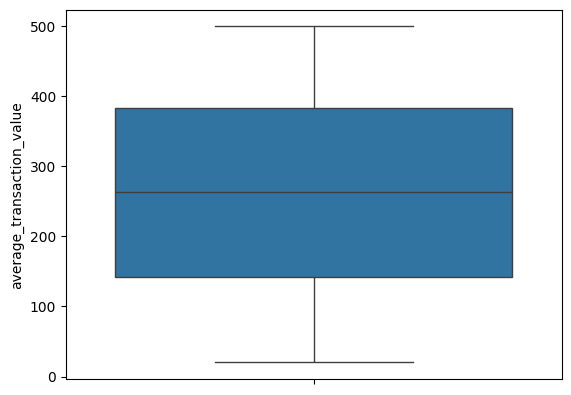

In [165]:
sns.boxplot(df['average_transaction_value'])

<Axes: ylabel='total_bank_balance'>

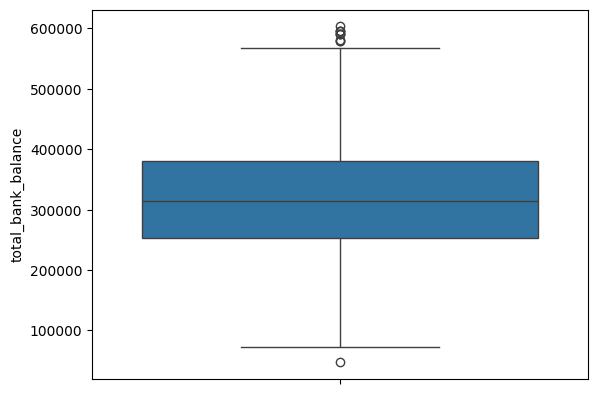

In [166]:
sns.boxplot(df['total_bank_balance'])

<Axes: ylabel='loyalty_score'>

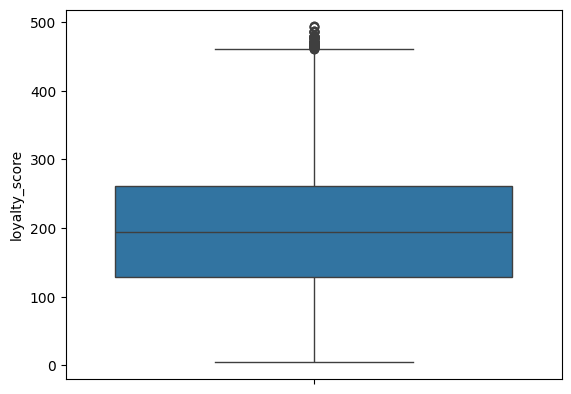

In [167]:
sns.boxplot(df['loyalty_score'])

<Axes: ylabel='monthly_spend_cash'>

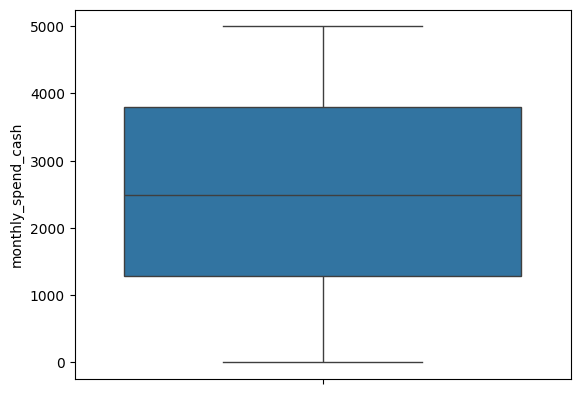

In [168]:
sns.boxplot(df['monthly_spend_cash'])

<Axes: ylabel='monthly_spend_payments'>

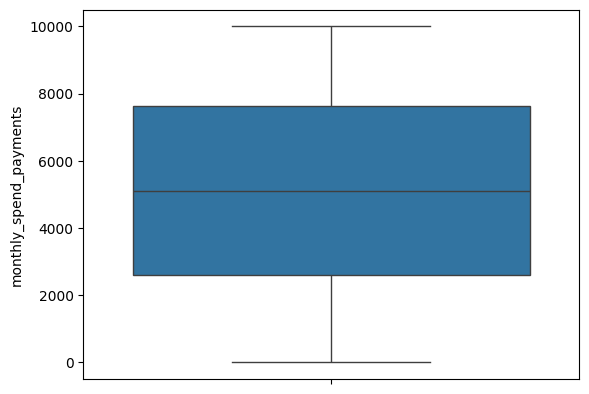

In [169]:
sns.boxplot(df['monthly_spend_payments'])

<Axes: ylabel='monthly_spend_installments'>

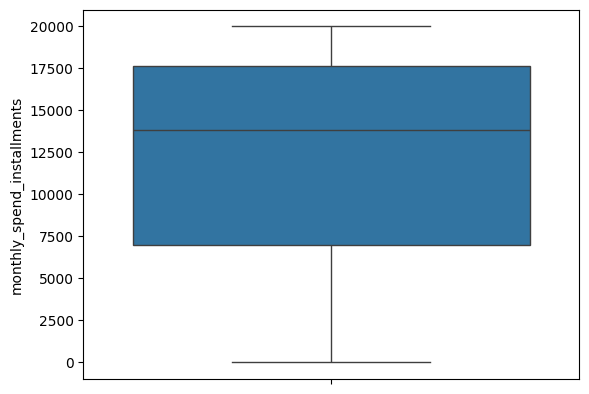

In [170]:
sns.boxplot(df['monthly_spend_installments'])

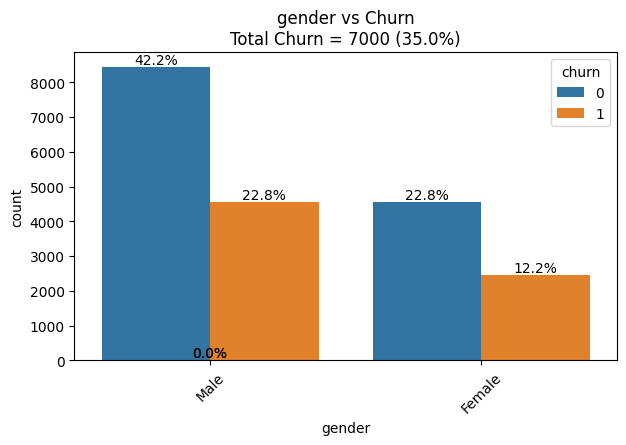

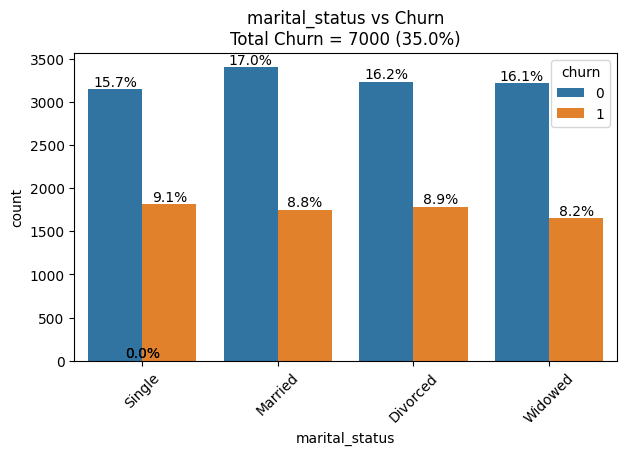

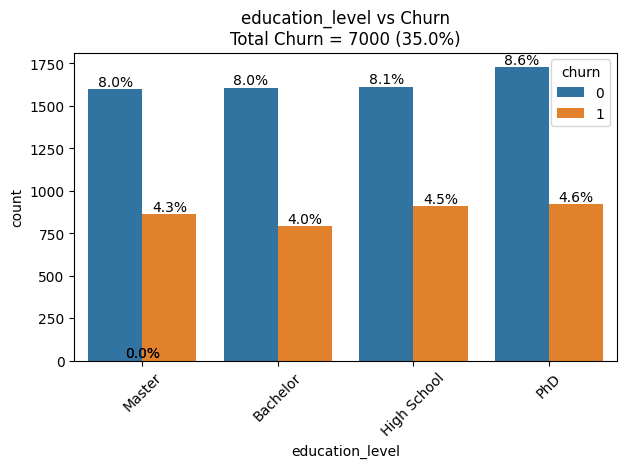

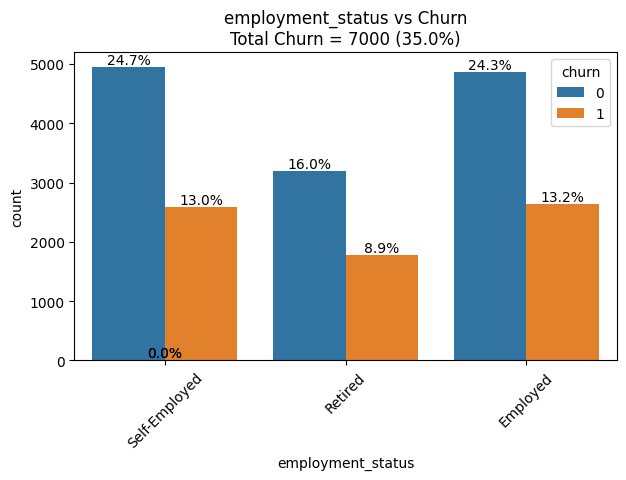

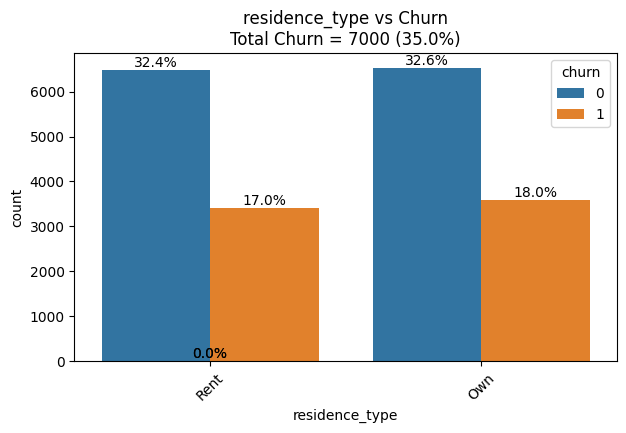

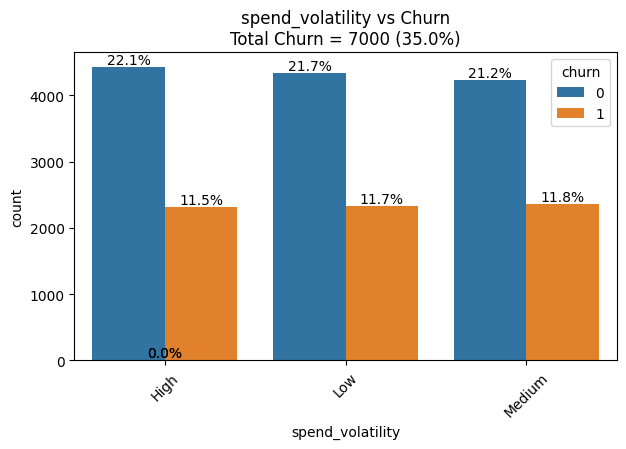

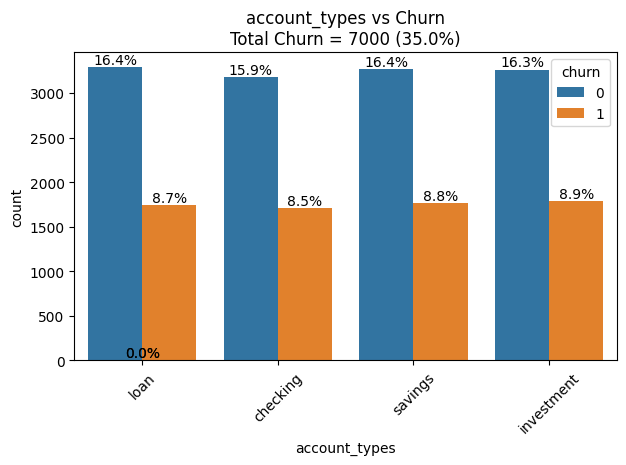

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


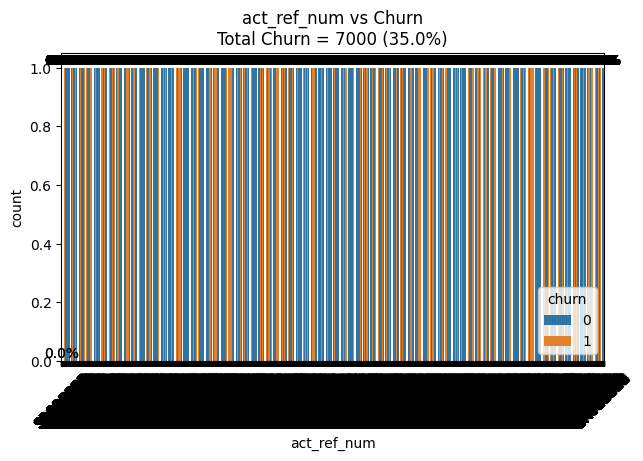

In [171]:
cat_cols = df.select_dtypes(include='object').columns.drop('plastic_masked_pan')

for col in cat_cols:
    plt.figure(figsize=(7,4))

    ax = sns.countplot(
        data=df,
        x=col,
        hue='churn'
    )

    total = len(df)

    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom'
        )

    total_churn = df['churn'].sum()
    churn_percentage = df['churn'].mean() * 100

    plt.title(
        f'{col} vs Churn\nTotal Churn = {total_churn} ({churn_percentage:.1f}%)'
    )

    plt.xticks(rotation=45)
    plt.show()

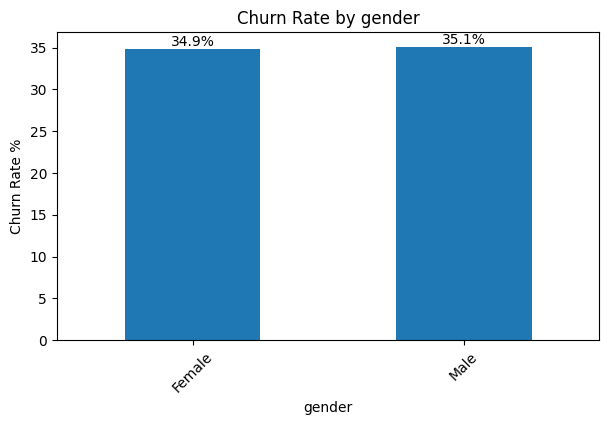

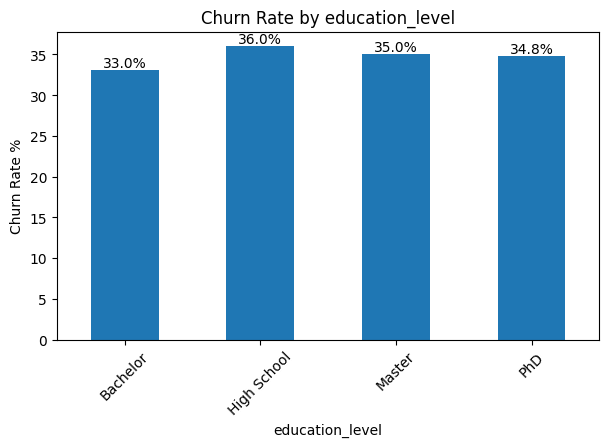

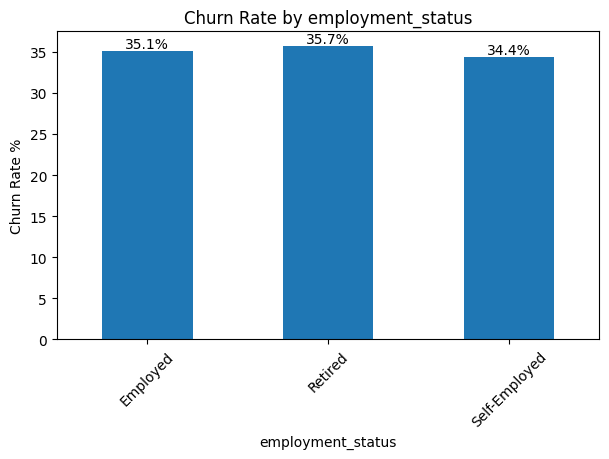

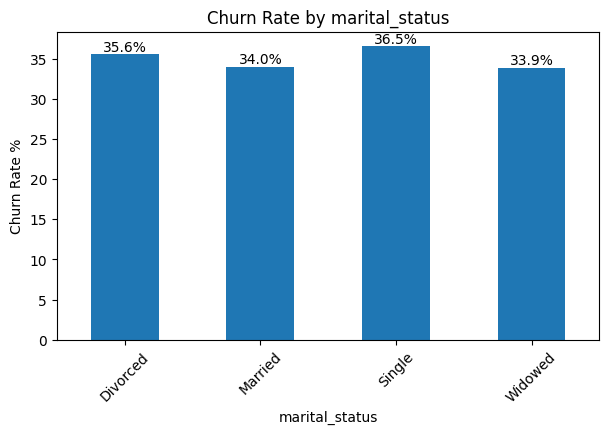

In [172]:
categorical_features = [
    'gender',
    'education_level',
    'employment_status',
    'marital_status'
]


for col in categorical_features:

    churn_rate = (
        df.groupby(col)['churn']
        .mean()
        *100
    )

    plt.figure(figsize=(7,4))

    ax = churn_rate.plot(
        kind='bar'
    )

    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate %")
    plt.xlabel(col)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

    plt.xticks(rotation=45)

    plt.show()

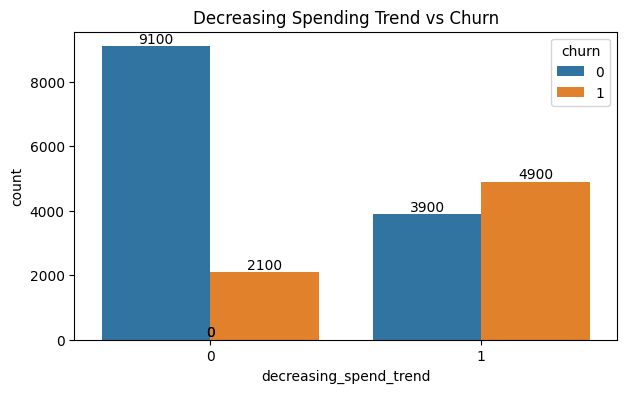

In [173]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x='decreasing_spend_trend',
    hue='churn'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Decreasing Spending Trend vs Churn")

plt.show()

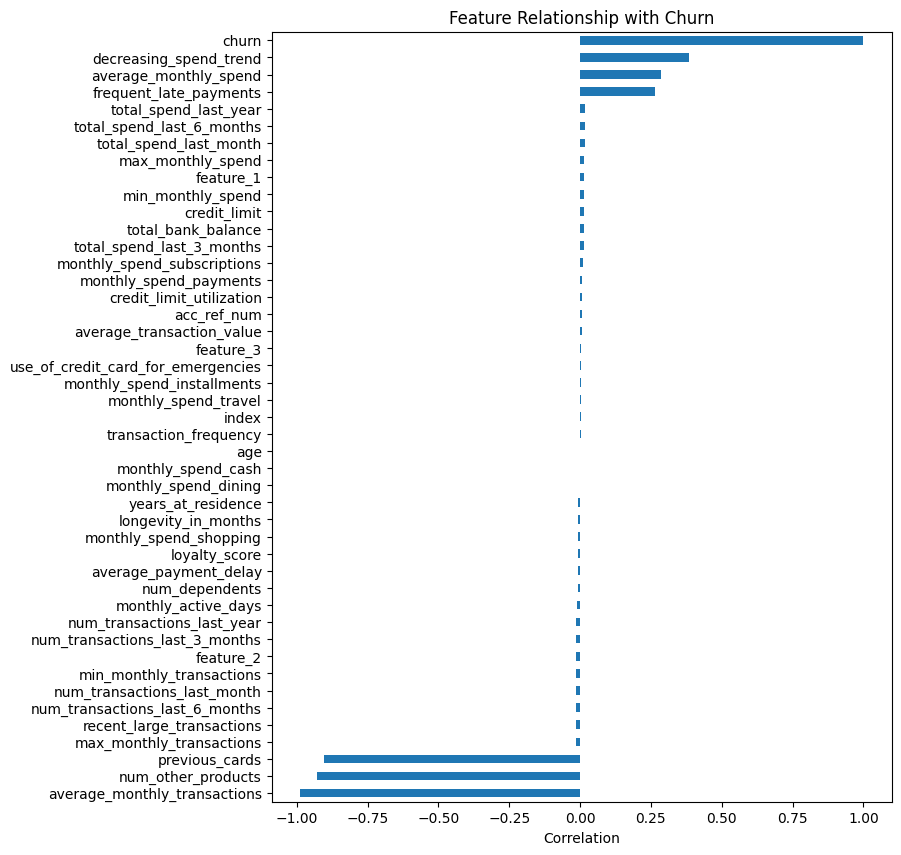

In [174]:
churn_corr = (
    df.select_dtypes('number')
    .corr()['churn']
    .sort_values()
)


plt.figure(figsize=(8,10))

churn_corr.plot(
    kind='barh'
)

plt.title(
    "Feature Relationship with Churn"
)

plt.xlabel("Correlation")

plt.show()

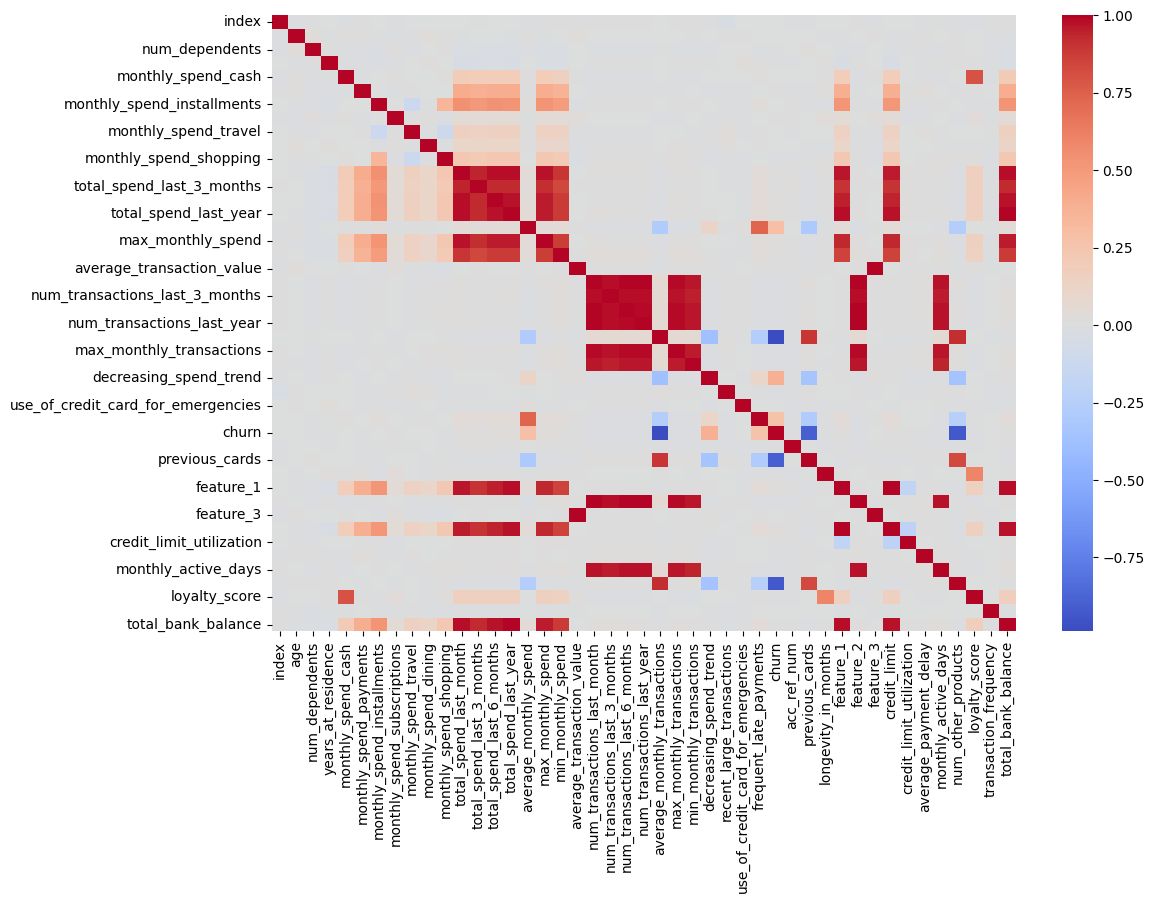

In [175]:
# technical
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes('number').corr(),
    cmap='coolwarm'
)

plt.show()

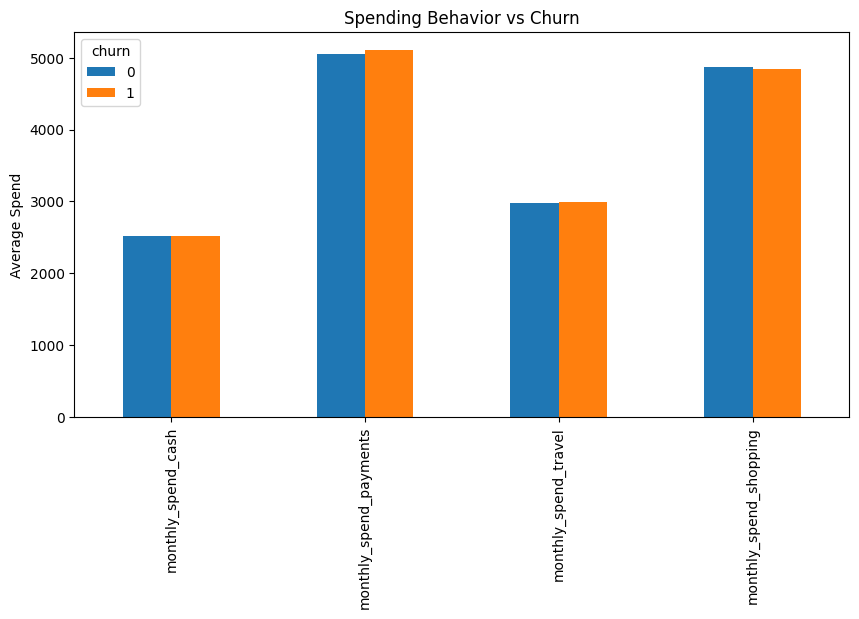

In [176]:
spend_cols = [
    'monthly_spend_cash',
    'monthly_spend_payments',
    'monthly_spend_travel',
    'monthly_spend_shopping'
]


df.groupby('churn')[spend_cols].mean().T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel("Average Spend")
plt.title("Spending Behavior vs Churn")

plt.show()

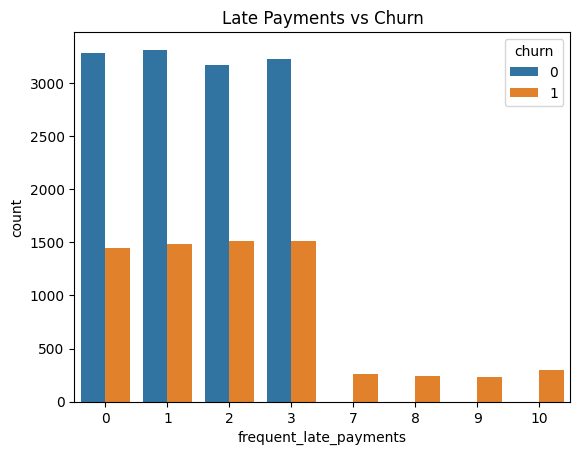

In [177]:
sns.countplot(
    data=df,
    x='frequent_late_payments',
    hue='churn'
)

plt.title("Late Payments vs Churn")
plt.show()

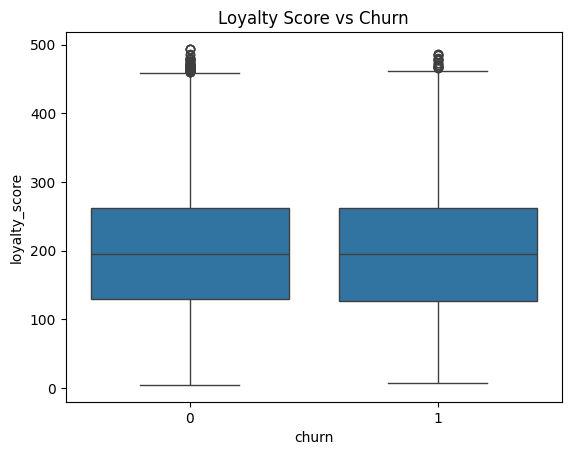

In [178]:
sns.boxplot(
    data=df,
    x='churn',
    y='loyalty_score'
)

plt.title("Loyalty Score vs Churn")
plt.show()

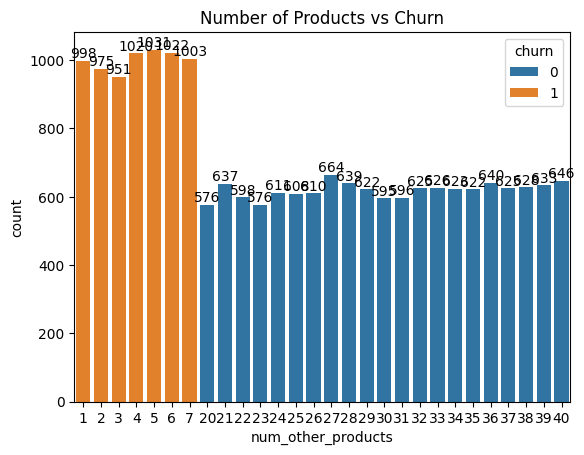

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the countplot and assign it to 'ax'
ax = sns.countplot(
    data=df,
    x='num_other_products',
    hue='churn'
)

# Iterate through the bar containers and add the labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Products vs Churn")
plt.show()

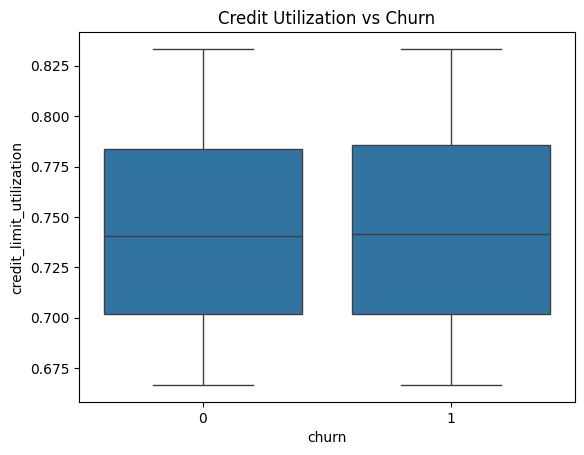

In [180]:
sns.boxplot(
    data=df,
    x='churn',
    y='credit_limit_utilization'
)

plt.title("Credit Utilization vs Churn")
plt.show()



---
# DATA PREPARATION


---



In [181]:
df.drop(columns=['feature_1','feature_2','feature_3'], inplace=True)

In [182]:
df.drop('index', axis=1, inplace= True)

In [183]:
df.drop(['acc_ref_num'], axis=1, inplace = True)

In [184]:
df = df.set_index('act_ref_num')

# NULL HANDELING

In [185]:
df['education_level'] = df['education_level'].fillna('Unknown')

In [186]:
df['average_transaction_value'] = df['average_transaction_value'].fillna(df['average_transaction_value'].mean())

In [187]:
df['total_bank_balance'] = df['total_bank_balance'].fillna(df['total_bank_balance'].median())

In [188]:
df['loyalty_score'] = df['loyalty_score'].fillna(df['loyalty_score'].median())

In [189]:
df['monthly_spend_cash'] = df['monthly_spend_cash'].fillna(df['monthly_spend_cash'].mean())

In [190]:
df['monthly_spend_payments'] = df['monthly_spend_payments'].fillna(df['monthly_spend_payments'].mean())

In [191]:
df['monthly_spend_installments'] = df['monthly_spend_installments'].fillna(df['monthly_spend_installments'].mean())

In [192]:
df.isnull().sum().sort_values(ascending=0)

,0
age,0
gender,0
marital_status,0
education_level,0
employment_status,0
num_dependents,0
residence_type,0
years_at_residence,0
monthly_spend_cash,0
monthly_spend_payments,0


## No duplicates

In [193]:
df.duplicated().sum()

np.int64(0)

In [194]:
df

,age,gender,marital_status,education_level,employment_status,num_dependents,residence_type,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_month,total_spend_last_3_months,total_spend_last_6_months,total_spend_last_year,average_monthly_spend,max_monthly_spend,min_monthly_spend,average_transaction_value,num_transactions_last_month,num_transactions_last_3_months,num_transactions_last_6_months,num_transactions_last_year,average_monthly_transactions,max_monthly_transactions,min_monthly_transactions,decreasing_spend_trend,spend_volatility,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,expiration_date,previous_cards,longevity_in_months,credit_limit,credit_limit_utilization,average_payment_delay,monthly_active_days,num_other_products,account_types,loyalty_score,transaction_frequency,total_bank_balance,plastic_masked_pan
act_ref_num,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SR010651,22,Male,Single,Master,Self-Employed,3,Rent,3,4664.000000,7438.000000,15398.000000,760,4884.056742,2211,6555.000000,40001,134147.488984,229021.456622,510289.503743,39761.617291,48092.489848,20537.322607,179.320620,19,56,121,230,13,26,10,1,High,0,1,8,1,2025-08-27 19:02:25.599,1,37,760000,0.675217,0,0.542960,4,loan,251.70,44,514953.503743,**** **** **** 4691
SR002042,25,Male,Married,Unknown,Retired,2,Rent,1,2517.592994,8252.000000,18864.429771,665,2970.000000,920,6430.319172,32342,101638.757719,196935.466907,367657.989538,14146.186657,40624.516991,17692.040772,331.481110,74,240,437,854,170,101,45,0,Low,1,1,3,0,2025-07-27 19:02:25.599,9,95,510000,0.730798,0,2.918925,40,checking,194.65,24,314843.408621,**** **** **** 4806
SR008669,64,Female,Divorced,Bachelor,Employed,4,Own,8,1408.000000,5199.000000,4964.000000,882,1167.000000,2418,4967.000000,21005,52898.328993,117662.365738,237161.720388,17565.195841,28874.282596,12457.854688,283.348730,18,51,104,220,12,24,11,1,High,0,0,2,1,2024-10-12 19:02:25.599,1,47,310000,0.783904,0,0.705561,7,checking,93.90,42,238569.720388,**** **** **** 2237
SR001115,61,Female,Single,Master,Employed,2,Own,8,2517.592994,1837.000000,18270.000000,722,4808.275207,43,5992.000000,30275,86390.416083,188754.429687,370750.224323,19681.613661,38812.702037,17246.958911,121.543290,35,111,223,390,15,44,26,1,High,1,1,3,1,2028-10-13 19:02:25.599,2,187,520000,0.725752,0,0.935237,4,loan,194.65,10,314843.408621,**** **** **** 6982
SR013903,58,Male,Married,Unknown,Self-Employed,1,Rent,14,4134.000000,7530.000000,18272.775610,166,3256.000000,2736,7506.437574,23050,74438.420532,145501.563858,286910.970994,20698.827145,27802.368773,16321.431566,97.689565,69,185,391,774,14,99,44,1,High,1,1,0,1,2027-04-22 19:02:25.599,1,120,400000,0.721720,3,2.471756,6,checking,266.70,39,291044.970994,**** **** **** 5168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SR011285,34,Female,Widowed,Master,Retired,2,Rent,13,2517.592994,2869.000000,3369.000000,683,2247.000000,1953,2924.000000,17020,56650.897974,99084.441369,196629.209964,17954.266075,23248.006027,11280.015406,262.483840,9,28,49,112,159,11,4,0,High,0,0,1,0,2027-12-27 19:02:25.599,5,210,290000,0.683099,3,0.319302,28,loan,194.65,38,314843.408621,**** **** **** 5520
SR011965,25,Male,Married,Unknown,Employed,4,Own,15,2517.592994,3987.000000,19475.274586,528,70.000000,1927,7411.929949,25311,81321.606158,142982.878781,322237.840685,18898.135158,31202.082261,15129.400019,262.483840,51,145,281,592,199,63,27,0,Low,0,0,0,0,2026-10-07 19:02:25.599,5,422,440000,0.732904,6,1.603575,25,checking,194.65,15,314843.408621,**** **** **** 8807
SR005391,39,Male,Married,Bachelor,Self-Employed,1,Rent,1,283.000000,1919.000000,18531.312180,478,61.000000,743,6946.466655,17227,52315.852236,98136.8142

In [195]:
df.dtypes

,0
age,int64
gender,object
marital_status,object
education_level,object
employment_status,object
num_dependents,int64
residence_type,object
years_at_residence,int64
monthly_spend_cash,float64
monthly_spend_payments,float64


In [196]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Date columns
date_cols = df.select_dtypes(include=['datetime64']).columns

print("Numerical:")
print(num_cols)

print("\nCategorical:")
print(cat_cols)

print("\nDate:")
print(date_cols)

Numerical:
Index(['age', 'num_dependents', 'years_at_residence', 'monthly_spend_cash',
       'monthly_spend_payments', 'monthly_spend_installments',
       'monthly_spend_subscriptions', 'monthly_spend_travel',
       'monthly_spend_dining', 'monthly_spend_shopping',
       'total_spend_last_month', 'total_spend_last_3_months',
       'total_spend_last_6_months', 'total_spend_last_year',
       'average_monthly_spend', 'max_monthly_spend', 'min_monthly_spend',
       'average_transaction_value', 'num_transactions_last_month',
       'num_transactions_last_3_months', 'num_transactions_last_6_months',
       'num_transactions_last_year', 'average_monthly_transactions',
       'max_monthly_transactions', 'min_monthly_transactions',
       'decreasing_spend_trend', 'recent_large_transactions',
       'use_of_credit_card_for_emergencies', 'frequent_late_payments', 'churn',
       'previous_cards', 'longevity_in_months', 'credit_limit',
       'credit_limit_utilization', 'average_payment_de

In [197]:
# Drop Plastic masked pan
df.drop(['plastic_masked_pan'], axis=1, inplace = True)

# ***Feature Engineering***


---



In [198]:
# Convert column to datetime
df['expiration_date'] = pd.to_datetime(df['expiration_date'])

# Calculate days until expiration
df['days_to_expire'] = (df['expiration_date'] - pd.Timestamp.today()).dt.days

In [199]:
df.drop('expiration_date', axis=1, inplace=True)

# ***ENCODING***

In [200]:
# Education Level Ordinal Encoding
education_order = {
    'Unknown': 0,
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

df['education_level'] = df['education_level'].map(education_order)


# Spend Volatility Ordinal Encoding
volatility_order = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

df['spend_volatility'] = df['spend_volatility'].map(volatility_order)


# Check
print(df[['education_level', 'spend_volatility']].head())

             education_level  spend_volatility
act_ref_num                                   
SR010651                   3                 2
SR002042                   0                 0
SR008669                   2                 2
SR001115                   3                 2
SR013903                   0                 2


In [201]:
nominal_cols = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'account_types'
]

df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

In [202]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, SR010651 to SR015796
Data columns (total 53 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 20000 non-null  int64  
 1   education_level                     20000 non-null  int64  
 2   num_dependents                      20000 non-null  int64  
 3   years_at_residence                  20000 non-null  int64  
 4   monthly_spend_cash                  20000 non-null  float64
 5   monthly_spend_payments              20000 non-null  float64
 6   monthly_spend_installments          20000 non-null  float64
 7   monthly_spend_subscriptions         20000 non-null  int64  
 8   monthly_spend_travel                20000 non-null  float64
 9   monthly_spend_dining                20000 non-null  int64  
 10  monthly_spend_shopping              20000 non-null  float64
 11  total_spend_last_month              

In [204]:
pd.set_option('display.max_columns', None)

Full columns

In [205]:
df

,age,education_level,num_dependents,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_month,total_spend_last_3_months,total_spend_last_6_months,total_spend_last_year,average_monthly_spend,max_monthly_spend,min_monthly_spend,average_transaction_value,num_transactions_last_month,num_transactions_last_3_months,num_transactions_last_6_months,num_transactions_last_year,average_monthly_transactions,max_monthly_transactions,min_monthly_transactions,decreasing_spend_trend,spend_volatility,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,previous_cards,longevity_in_months,credit_limit,credit_limit_utilization,average_payment_delay,monthly_active_days,num_other_products,loyalty_score,transaction_frequency,total_bank_balance,days_to_expire,gender_Male,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-Employed,residence_type_Rent,account_types_investment,account_types_loan,account_types_savings
act_ref_num,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SR010651,22,3,3,3,4664.000000,7438.000000,15398.000000,760,4884.056742,2211,6555.000000,40001,134147.488984,229021.456622,510289.503743,39761.617291,48092.489848,20537.322607,179.320620,19,56,121,230,13,26,10,1,2,0,1,8,1,1,37,760000,0.675217,0,0.542960,4,251.70,44,514953.503743,-328,1,0,1,0,0,1,1,0,1,0
SR002042,25,0,2,1,2517.592994,8252.000000,18864.429771,665,2970.000000,920,6430.319172,32342,101638.757719,196935.466907,367657.989538,14146.186657,40624.516991,17692.040772,331.481110,74,240,437,854,170,101,45,0,0,1,1,3,0,9,95,510000,0.730798,0,2.918925,40,194.65,24,314843.408621,-359,1,1,0,0,1,0,1,0,0,0
SR008669,64,2,4,8,1408.000000,5199.000000,4964.000000,882,1167.000000,2418,4967.000000,21005,52898.328993,117662.365738,237161.720388,17565.195841,28874.282596,12457.854688,283.348730,18,51,104,220,12,24,11,1,2,0,0,2,1,1,47,310000,0.783904,0,0.705561,7,93.90,42,238569.720388,-647,0,0,0,0,0,0,0,0,0,0
SR001115,61,3,2,8,2517.592994,1837.000000,18270.000000,722,4808.275207,43,5992.000000,30275,86390.416083,188754.429687,370750.224323,19681.613661,38812.702037,17246.958911,121.543290,35,111,223,390,15,44,26,1,2,1,1,3,1,2,187,520000,0.725752,0,0.935237,4,194.65,10,314843.408621,815,0,0,1,0,0,0,0,0,1,0
SR013903,58,0,1,14,4134.000000,7530.000000,18272.775610,166,3256.000000,2736,7506.437574,23050,74438.420532,145501.563858,286910.970994,20698.827145,27802.368773,16321.431566,97.689565,69,185,391,774,14,99,44,1,2,1,1,0,1,1,120,400000,0.721720,3,2.471756,6,266.70,39,291044.970994,275,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SR011285,34,3,2,13,2517.592994,2869.000000,3369.000000,683,2247.000000,1953,2924.000000,17020,56650.897974,99084.441369,196629.209964,17954.266075,23248.006027,11280.015406,262.483840,9,28,49,112,159,11,4,0,2,0,0,1,0,5,210,290000,0.683099,3,0.319302,28,194.65,38,314843.408621,524,0,0,0,1,1,0,1,0,1,0
SR011965,25,0,4,15,2517.592994,3987.000000,19475.274586,528,70.000000,1927,7411.929949,25311,81321.606158,142982.878781,322237.840685,18898.135158,31202.082261,15129.400019,262.483840,51,145,281,592,199,63,27,0,0,0,0,0,0,5,422,440000,0.732904,6,1.603575,25,194.65,15,314843.408621,78,1,1,0,0,0,0,0,0,0,0
SR005391,39,2,1,1,283.000000,1919.000000,18531.312180,478,61.000000,743,6946.466655,17227,52315.852236,98136.814226,201917.067921,14805.122050,22689.769570,13312.349529,262.483840,69,186,409,824,7,103,44,1,1,0,0,1,1,2,216,260000,0.805260,0,2.186324,6,122.15,23,202200.067921,-669,1,1,0,0,0,1,1,0,0,1




---


# ***Feature Selection***
---



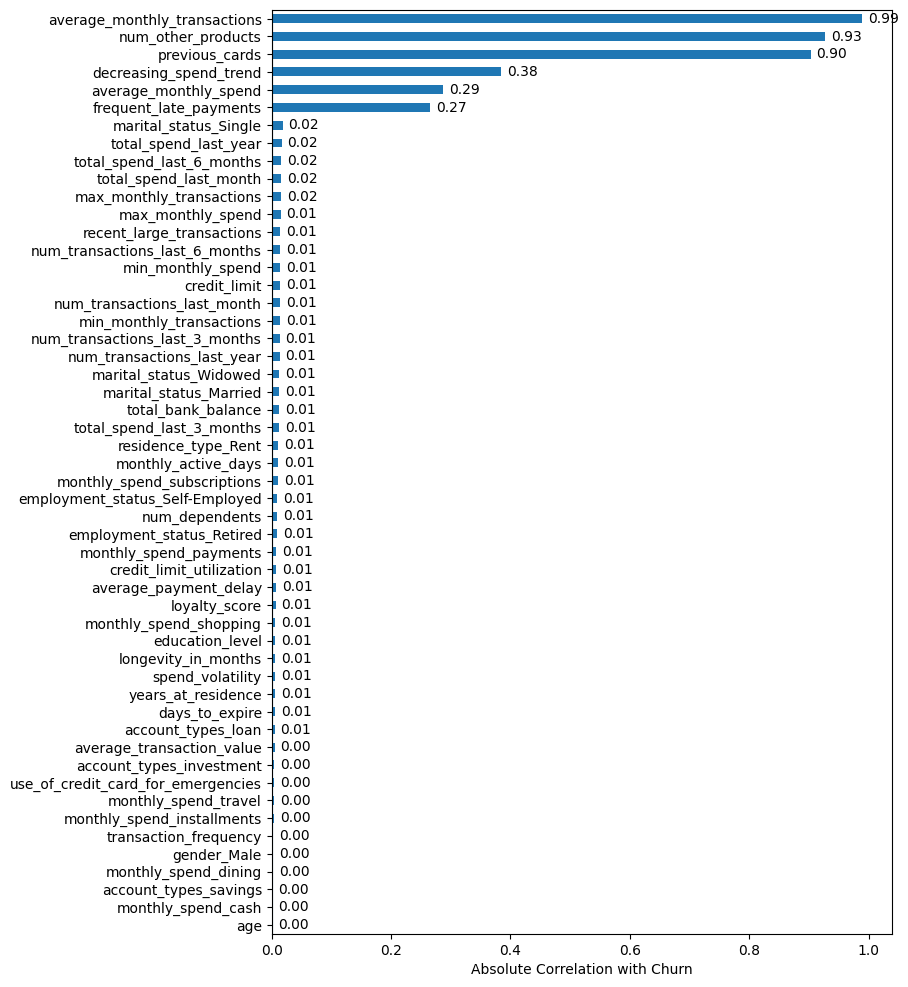

In [206]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)['churn'].drop('churn').abs()

corr_sorted = corr.sort_values()

ax = corr_sorted.plot(kind='barh', figsize=(8,12))

for i, value in enumerate(corr_sorted):
    ax.text(value + 0.01, i, f'{value:.2f}', va='center')

plt.axvline(0)
plt.xlabel("Absolute Correlation with Churn")
plt.show()

In [207]:
corr_matrix = df.drop(columns='churn').corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

report = (
    corr_matrix.where(mask)
    .stack()
    .reset_index()
)

report.columns = [
    'Feature_1',
    'Feature_2',
    'Feature_Correlation'
]

90th percentile: 0.11517956958833009
95th percentile: 0.43254719954392795
97th percentile: 0.9096086775773331
98th percentile: 0.9523704290557469
99th percentile: 0.9725851716013172


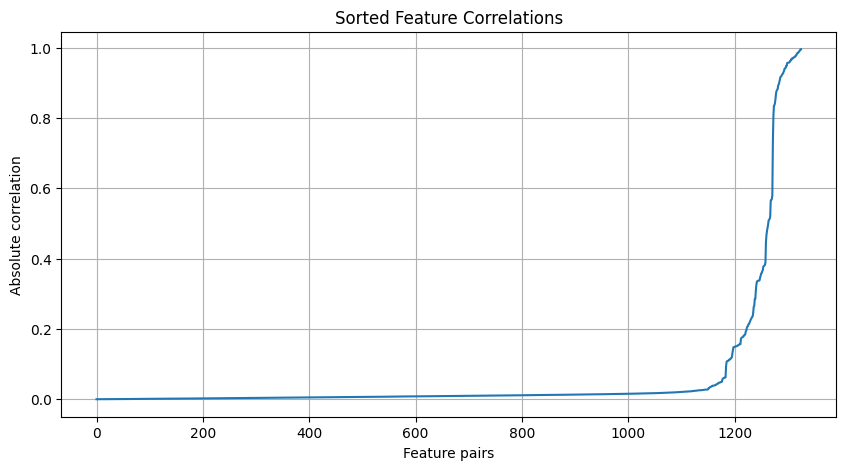

In [208]:

import numpy as np
import matplotlib.pyplot as plt

# Absolute correlations between features
corr_values = report['Feature_Correlation'].abs().sort_values()

# Calculate percentiles
for p in [90, 95, 97, 98, 99]:
    print(f"{p}th percentile:", corr_values.quantile(p/100))

# Plot sorted correlations
plt.figure(figsize=(10,5))
plt.plot(range(len(corr_values)), corr_values.values)

plt.xlabel("Feature pairs")
plt.ylabel("Absolute correlation")
plt.title("Sorted Feature Correlations")

plt.grid()
plt.show()

In [209]:

def correlation_feature_selection(
    df,
    target,
    target_threshold,
    feature_threshold
):

    df_selected = df.copy()

    # 1. Drop features highly correlated with target
    corr = df_selected.corr().abs()[target]

    target_related_features = corr[
        (corr > target_threshold) & (corr.index != target)
    ].index.tolist()

    df_selected = df_selected.drop(columns=target_related_features)

    # 2. Remove highly correlated features with each other
    corr_matrix = df_selected.corr().abs()

    target_corr = corr_matrix[target]

    features_to_drop = set()

    columns = corr_matrix.columns.drop(target)

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            feature1 = columns[i]
            feature2 = columns[j]

            if corr_matrix.loc[feature1, feature2] > feature_threshold:

                corr1 = target_corr[feature1]
                corr2 = target_corr[feature2]

                # Keep the feature with higher correlation with target
                if corr1 >= corr2:
                    features_to_drop.add(feature2)
                else:
                    features_to_drop.add(feature1)

    df_selected = df_selected.drop(columns=list(features_to_drop))

    # Results
    all_dropped_features = target_related_features + list(features_to_drop)

    print("Features dropped:")
    print(sorted(all_dropped_features))

    print("\nNumber of dropped features:", len(all_dropped_features))

    print("\nOriginal number of columns:", df.shape[1])
    print("Final number of columns:", df_selected.shape[1])

    return df_selected, all_dropped_features


df_selected, dropped_features = correlation_feature_selection(
    df=df,
    target="churn",
    target_threshold=0.90,
    feature_threshold=0.90
)

Features dropped:
['average_monthly_transactions', 'credit_limit', 'max_monthly_spend', 'min_monthly_transactions', 'monthly_active_days', 'num_other_products', 'num_transactions_last_3_months', 'num_transactions_last_6_months', 'num_transactions_last_month', 'num_transactions_last_year', 'previous_cards', 'total_bank_balance', 'total_spend_last_3_months', 'total_spend_last_6_months', 'total_spend_last_month']

Number of dropped features: 15

Original number of columns: 53
Final number of columns: 38


# ***Modeling***

In [210]:
df_selected

,age,education_level,num_dependents,years_at_residence,monthly_spend_cash,monthly_spend_payments,monthly_spend_installments,monthly_spend_subscriptions,monthly_spend_travel,monthly_spend_dining,monthly_spend_shopping,total_spend_last_year,average_monthly_spend,min_monthly_spend,average_transaction_value,max_monthly_transactions,decreasing_spend_trend,spend_volatility,recent_large_transactions,use_of_credit_card_for_emergencies,frequent_late_payments,churn,longevity_in_months,credit_limit_utilization,average_payment_delay,loyalty_score,transaction_frequency,days_to_expire,gender_Male,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-Employed,residence_type_Rent,account_types_investment,account_types_loan,account_types_savings
act_ref_num,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SR010651,22,3,3,3,4664.000000,7438.000000,15398.000000,760,4884.056742,2211,6555.000000,510289.503743,39761.617291,20537.322607,179.320620,26,1,2,0,1,8,1,37,0.675217,0,251.70,44,-328,1,0,1,0,0,1,1,0,1,0
SR002042,25,0,2,1,2517.592994,8252.000000,18864.429771,665,2970.000000,920,6430.319172,367657.989538,14146.186657,17692.040772,331.481110,101,0,0,1,1,3,0,95,0.730798,0,194.65,24,-359,1,1,0,0,1,0,1,0,0,0
SR008669,64,2,4,8,1408.000000,5199.000000,4964.000000,882,1167.000000,2418,4967.000000,237161.720388,17565.195841,12457.854688,283.348730,24,1,2,0,0,2,1,47,0.783904,0,93.90,42,-647,0,0,0,0,0,0,0,0,0,0
SR001115,61,3,2,8,2517.592994,1837.000000,18270.000000,722,4808.275207,43,5992.000000,370750.224323,19681.613661,17246.958911,121.543290,44,1,2,1,1,3,1,187,0.725752,0,194.65,10,815,0,0,1,0,0,0,0,0,1,0
SR013903,58,0,1,14,4134.000000,7530.000000,18272.775610,166,3256.000000,2736,7506.437574,286910.970994,20698.827145,16321.431566,97.689565,99,1,2,1,1,0,1,120,0.721720,3,266.70,39,275,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SR011285,34,3,2,13,2517.592994,2869.000000,3369.000000,683,2247.000000,1953,2924.000000,196629.209964,17954.266075,11280.015406,262.483840,11,0,2,0,0,1,0,210,0.683099,3,194.65,38,524,0,0,0,1,1,0,1,0,1,0
SR011965,25,0,4,15,2517.592994,3987.000000,19475.274586,528,70.000000,1927,7411.929949,322237.840685,18898.135158,15129.400019,262.483840,63,0,0,0,0,0,0,422,0.732904,6,194.65,15,78,1,1,0,0,0,0,0,0,0,0
SR005391,39,2,1,1,283.000000,1919.000000,18531.312180,478,61.000000,743,6946.466655,201917.067921,14805.122050,13312.349529,262.483840,103,1,1,0,0,1,1,216,0.805260,0,122.15,23,-669,1,1,0,0,0,1,1,0,0,1


In [211]:
!pip install lazypredict

In [212]:
import lazypredict

In [213]:
from lazypredict.Supervised import LazyClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_selected.drop("churn", axis=1)
y = df_selected["churn"]

# Train / Validation / Test Split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=38,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.176,
    random_state=38,
    stratify=y_train_val
)


# Scaling (fit only on training data)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)


# Try all sklearn classification models
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True
)

models, predictions = clf.fit(
    X_train,
    X_val,
    y_train,
    y_val
)

print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
AdaBoostClassifier             0.725602           0.734927  0.758545   
NearestCentroid                0.715575           0.703844  0.749961   
SGDClassifier                  0.725602           0.691271  0.746120   
SVC                            0.717246           0.675143  0.759562   
LinearDiscriminantAnalysis     0.710561           0.670663  0.750077   
CalibratedClassifierCV         0.710896           0.669377  0.749993   
LGBMClassifier                 0.722594           0.669114  0.760644   
LinearSVC                      0.711230           0.665224  0.749968   
LogisticRegression             0.711230           0.665003  0.749518   
RidgeClassifier                0.712567           0.664929  0.750076   
RidgeClassifierCV              0.712233           0.664672  0.750072   
ExtraTreesClassifier           0.719251           0.663015  0.75

In [143]:
from sklearn.ensemble import AdaBoostClassifier
import joblib

# Create model
best_model = AdaBoostClassifier(random_state=38)

# Train it
best_model.fit(X_train, y_train)

# Save model
joblib.dump(best_model, "adaboost_churn_model.pkl")

['adaboost_churn_model.pkl']

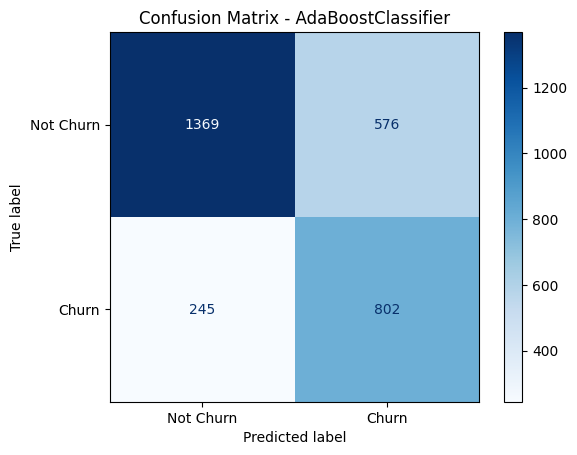

In [144]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train AdaBoost
model = AdaBoostClassifier(random_state=38)

model.fit(X_train, y_train)

# Predict validation set
y_pred = model.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - AdaBoostClassifier")
plt.show()

            Precision    Recall  F1-score
Training     0.565306  0.734448  0.638872
Validation   0.582003  0.765998  0.661443


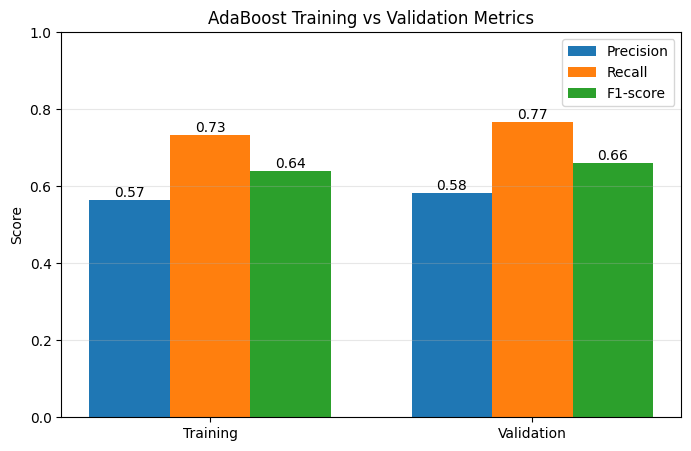

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# =========================
# Predictions
# =========================

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)


# =========================
# Calculate Metrics
# =========================

metrics = pd.DataFrame(
    {
        "Precision": [
            precision_score(y_train, y_train_pred),
            precision_score(y_val, y_val_pred)
        ],
        "Recall": [
            recall_score(y_train, y_train_pred),
            recall_score(y_val, y_val_pred)
        ],
        "F1-score": [
            f1_score(y_train, y_train_pred),
            f1_score(y_val, y_val_pred)
        ]
    },
    index=["Training", "Validation"]
)


print(metrics)


# =========================
# Plot
# =========================

labels = ["Training", "Validation"]

x = range(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

precision_bars = plt.bar(
    [i - width for i in x],
    metrics["Precision"],
    width,
    label="Precision"
)

recall_bars = plt.bar(
    x,
    metrics["Recall"],
    width,
    label="Recall"
)

f1_bars = plt.bar(
    [i + width for i in x],
    metrics["F1-score"],
    width,
    label="F1-score"
)


plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("AdaBoost Training vs Validation Metrics")
plt.ylim(0, 1)


# Add values on bars
for bars in [precision_bars, recall_bars, f1_bars]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )


plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()



---

#***STACKING***

---



In [146]:
df.columns

Index(['age', 'education_level', 'num_dependents', 'years_at_residence',
       'monthly_spend_cash', 'monthly_spend_payments',
       'monthly_spend_installments', 'monthly_spend_subscriptions',
       'monthly_spend_travel', 'monthly_spend_dining',
       'monthly_spend_shopping', 'total_spend_last_month',
       'total_spend_last_3_months', 'total_spend_last_6_months',
       'total_spend_last_year', 'average_monthly_spend', 'max_monthly_spend',
       'min_monthly_spend', 'average_transaction_value',
       'num_transactions_last_month', 'num_transactions_last_3_months',
       'num_transactions_last_6_months', 'num_transactions_last_year',
       'average_monthly_transactions', 'max_monthly_transactions',
       'min_monthly_transactions', 'decreasing_spend_trend',
       'spend_volatility', 'recent_large_transactions',
       'use_of_credit_card_for_emergencies', 'frequent_late_payments', 'churn',
       'previous_cards', 'longevity_in_months', 'credit_limit',
       'credit_limi

In [147]:
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)


base_models = [
    ('ada', AdaBoostClassifier(random_state=38)),
    ('lgbm', LGBMClassifier(random_state=38)),
    ('svc', SVC(probability=True, random_state=38)),
    ('extra', ExtraTreesClassifier(random_state=38)),
    ('lda', LinearDiscriminantAnalysis())
]


meta_model = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=38
)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough = True,
    stack_method='predict_proba',
    n_jobs=-1
)


stacking_model.fit(
    X_train,
    y_train
)

StackingClassifier(cv=5,
                   estimators=[('ada', AdaBoostClassifier(random_state=38)),
                               ('lgbm', LGBMClassifier(random_state=38)),
                               ('svc', SVC(probability=True, random_state=38)),
                               ('extra', ExtraTreesClassifier(random_state=38)),
                               ('lda', LinearDiscriminantAnalysis())],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=5000,
                                                      random_state=38),
                   n_jobs=-1, passthrough=True, stack_method='predict_proba')

In [149]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Validation predictions
y_val_pred = stacking_model.predict(X_val)
y_val_proba = stacking_model.predict_proba(X_val)[:, 1]

# Overall metrics
accuracy = accuracy_score(y_val, y_val_pred)
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("===== Stacking Model Performance (Validation Set) =====")
print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_acc:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1 Score             : {f1:.4f}")
print(f"ROC AUC              : {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== Stacking Model Performance (Validation Set) =====
Accuracy             : 0.7256
Balanced Accuracy    : 0.7349
Precision            : 0.5820
Recall               : 0.7660
F1 Score             : 0.6614
ROC AUC              : 0.7548


# Feature Importance - LightGBM inside Stacking


                               Feature  Importance  Importance (%)
12               average_monthly_spend         197        6.566667
22            credit_limit_utilization         188        6.266667
8                 monthly_spend_travel         178        5.933333
26                      days_to_expire         153        5.100000
25               transaction_frequency         144        4.800000
7          monthly_spend_subscriptions         137        4.566667
24                       loyalty_score         136        4.533333
21                 longevity_in_months         134        4.466667
10              monthly_spend_shopping         134        4.466667
9                 monthly_spend_dining         133        4.433333
6           monthly_spend_installments         131        4.366667
4                   monthly_spend_cash         130        4.333333
14           average_transaction_value         126        4.200000
15            max_monthly_transactions         120        4.00

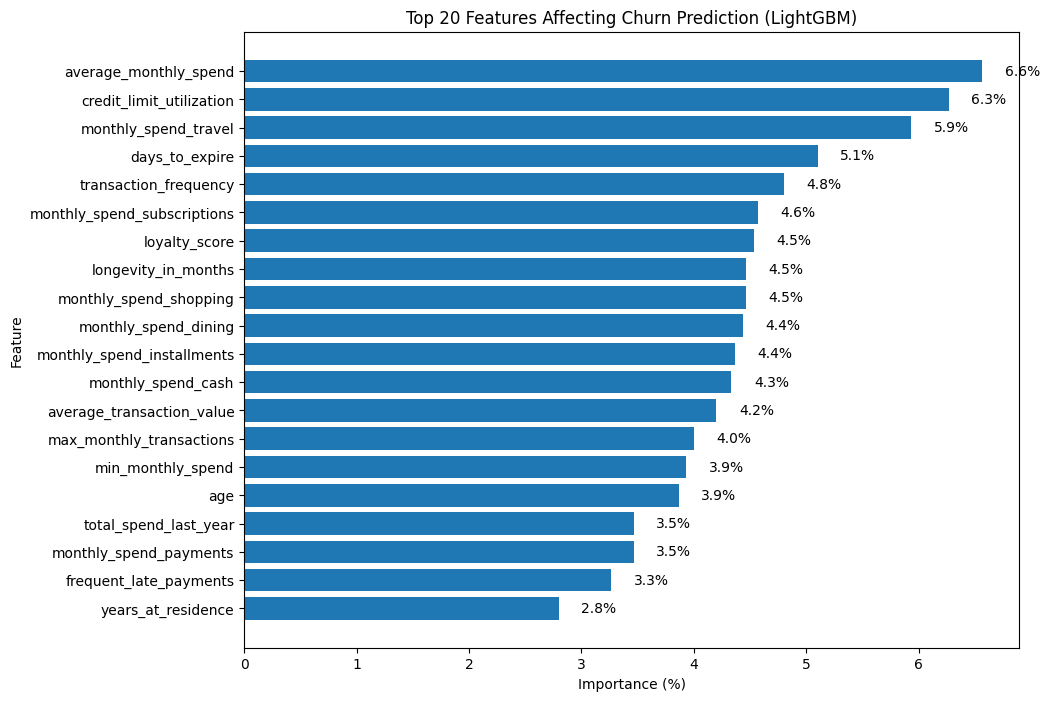

In [215]:
# =========================

# =========================

import pandas as pd
import matplotlib.pyplot as plt

# Extract LightGBM model from stacking
lgbm_model = stacking_model.named_estimators_['lgbm']

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
})

# Convert importance to percentage
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] /
    feature_importance["Importance"].sum()
) * 100

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance (%)",
    ascending=False
)

print(feature_importance)


# Plot top 20 features
top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

bars = plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance (%)"][::-1]
)

plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 20 Features Affecting Churn Prediction (LightGBM)")

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center"
    )

plt.show()



---


#***VOTING***
---



In [223]:
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================
# Base Models
# =========================
base_models = [
    ('ada', AdaBoostClassifier(random_state=38)),
    ('lgbm', LGBMClassifier(random_state=38)),
    ('svc', SVC(probability=True, random_state=38)),
    ('extra', ExtraTreesClassifier(random_state=38)),
    ('lda', LinearDiscriminantAnalysis())
]

# =========================
# Voting Classifier
# =========================
voting_model = VotingClassifier(
    estimators=base_models,
    voting='soft',
    n_jobs=-1
)

# =========================
# Train Model
# =========================
voting_model.fit(X_train, y_train)

# =========================
# Validation Predictions
# =========================
y_val_pred = voting_model.predict(X_val)
y_val_proba = voting_model.predict_proba(X_val)[:, 1]

# =========================
# Calculate Metrics
# =========================
accuracy = accuracy_score(y_val, y_val_pred)
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

# =========================
# Display Results
# =========================
print("===== Voting Model Performance (Validation Set) =====")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1 Score             : {f1:.4f}")
print(f"ROC AUC              : {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== Voting Model Performance (Validation Set) =====
Precision            : 0.6289
Recall               : 0.4986
F1 Score             : 0.5562
ROC AUC              : 0.7622


In [224]:
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================
# Base Models
# =========================
base_models = [
    ('ada', AdaBoostClassifier(random_state=38)),
    ('lgbm', LGBMClassifier(random_state=38)),
    ('svc', SVC(probability=True, random_state=38)),
    ('extra', ExtraTreesClassifier(random_state=38)),
    ('lda', LinearDiscriminantAnalysis())
]

# =========================
# Hard Voting Classifier
# =========================
voting_model = VotingClassifier(
    estimators=base_models,
    voting='hard',
    n_jobs=-1
)

# Train
voting_model.fit(X_train, y_train)

# Validation predictions
y_val_pred = voting_model.predict(X_val)

# Metrics
accuracy = accuracy_score(y_val, y_val_pred)
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("===== Hard Voting Model Performance (Validation Set) =====")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1 Score             : {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== Hard Voting Model Performance (Validation Set) =====
Precision            : 0.6041
Recall               : 0.5874
F1 Score             : 0.5956


In [226]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

def get_metrics(name, y_true, y_pred, y_proba=None):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else None
    }

results = []

# Stacking
y_pred = stacking_model.predict(X_val)
y_proba = stacking_model.predict_proba(X_val)[:, 1]
results.append(get_metrics("Stacking", y_val, y_pred, y_proba))

# Soft Voting
soft_voting = VotingClassifier(estimators=base_models, voting='soft', n_jobs=-1)
soft_voting.fit(X_train, y_train)
y_pred = soft_voting.predict(X_val)
y_proba = soft_voting.predict_proba(X_val)[:, 1]
results.append(get_metrics("Soft Voting", y_val, y_pred, y_proba))

# Hard Voting (no predict_proba, so ROC AUC is None)
hard_voting = VotingClassifier(estimators=base_models, voting='hard', n_jobs=-1)
hard_voting.fit(X_train, y_train)
y_pred = hard_voting.predict(X_val)
results.append(get_metrics("Hard Voting", y_val, y_pred, None))

comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


             Precision  Recall      F1  Balanced Acc  ROC AUC
Model                                                        
Stacking        0.5820  0.7660  0.6614        0.7349   0.7548
Soft Voting     0.6289  0.4986  0.5562        0.6701   0.7622
Hard Voting     0.6041  0.5874  0.5956        0.6901      NaN
